In [1]:
# load packages
import numpy as np 
import scipy.io
from scipy.io   import  loadmat
import pandas as pd
import os
import matplotlib.pyplot as plt #import matplotlib as plt
from scipy.optimize import curve_fit 
import seaborn as sns #import mat73
import pickle as pkl
from datetime import datetime
from itertools import chain
from scipy.optimize import curve_fit

In [2]:
from pathlib import Path
MainDir = Path.home() / "Desktop" / "Visual_Plasticty_Pipeline" / "Pipeline Processed Outputs" / "Cleaned_Local_RMS_Data" # 'Clean_PreS1_RMS_Data' 'Cleaned_Local_RMS_Data'
os.chdir(MainDir) # change old dir, to this dir
d = os.listdir(MainDir) # list files in dir
print(f'Avilable Files to choose from: {len(d)}')
print(f'Files on hand: {d}') 
FileN = d[0]#d[1] # choose one            
file_path1 = os.path.join(MainDir, FileN) # join paths and prep 2 load
print('Current WD:',file_path1) # does path exist ... ?
print('Does File #1 Exist?',os.path.exists(file_path1)) # yes or no
df = scipy.io.loadmat(file_path1) # RCA F1 File
print(df.keys())

Avilable Files to choose from: 3
Files on hand: ['rms_normalized_local_contrast_sweep_20260408_121516.mat', 'rms_normalized_local_contrast_sweep_20250918_160924.mat', 'rms_normalized_local_contrast_sweep_20260408_125433.mat']
Current WD: /Users/patricia.naomi/Desktop/Visual_Plasticty_Pipeline/Pipeline Processed Outputs/Cleaned_Local_RMS_Data/rms_normalized_local_contrast_sweep_20260408_121516.mat
Does File #1 Exist? True
dict_keys(['__header__', '__version__', '__globals__', 'F1_CleanData', 'F2_CleanData', 'Files_pSubj', 'Attn_Condition_pFile', 'TotFiles_pSubj', 'SessionOrder', 'Subj_ID'])


In [3]:
f1_data = df['F1_CleanData']
f2_data = df['F2_CleanData']
Subj_IDs = df['Subj_ID']

x = df['Files_pSubj'][0]
y = df['Attn_Condition_pFile'][0]
z = df['TotFiles_pSubj'][0]
t = df['SessionOrder'][0]
print(f1_data.shape)

(65, 2, 6)


In [4]:
print(Subj_IDs)

[[  2651   2652   2653   2654   2655   2657   2658   2659   2660   2661
    2663   2664   2665   2666   2667   2668   2669   2670   2672   2674
    2676   2677   2678   2695   2696   2697   2708   2715   2716   2726
    2727   2728   2733   2734   2737 345202 345215 345216]]


In [5]:
print(x) # subject files belonging to 1 person
print(y) # attention condition bool
print(z) # Day X per subect - this array lyk how many sessions 1 subj completed and what day it was
print(t) 

print(len(t))

[ 0  0  1  1  2  2  3  3  4  4  5  5  6  6  7  7  8  9  9 10 10 11 11 12
 12 13 13 14 14 15 15 16 16 17 17 18 18 19 19 20 21 21 22 23 23 24 24 25
 25 26 27 28 29 30 31 31 32 33 34 35 35 36 36 37 37]
[1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 1 0 0 0 1 0 1 0 1 0 1 0 1 0 0 1 0 1 1 0
 1 0 0 1 0 0 1 0 0 1 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 0 0 1]
[1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 1 2 1 1 2 1 2 1 2 1 1 1 1 1 1 2 1 1 1 1 2 1 2 1 2]
[1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 1 2 1 2 2 1
 1 2 1 2 1 1 2 1 1 2 1 2 1 1 1 1 1 2 1 1 1 1 1 2 1 2 2 1]
65


In [6]:
subj_per_session = Subj_IDs.flatten()[x]
print(subj_per_session)

[  2651   2651   2652   2652   2653   2653   2654   2654   2655   2655
   2657   2657   2658   2658   2659   2659   2660   2661   2661   2663
   2663   2664   2664   2665   2665   2666   2666   2667   2667   2668
   2668   2669   2669   2670   2670   2672   2672   2674   2674   2676
   2677   2677   2678   2695   2695   2696   2696   2697   2697   2708
   2715   2716   2726   2727   2728   2728   2733   2734   2737 345202
 345202 345215 345215 345216 345216]


In [7]:
exclude_NL = [2660, 2663, 2676, 2678, 2708, 2715, 2716, 2726, 2727, 2733, 2734, 2737] # 11 did 1 session only, 1 performed the same attentional condition 2x 
Subj_IDs_filtered = Subj_IDs[~np.isin(Subj_IDs, exclude_NL)]

print(f"Original N: {len(Subj_IDs.flatten())}")
print(f"Excluded N: {len(exclude_NL)}")
print(f"Remaining N: {len(Subj_IDs_filtered)}")
print(Subj_IDs_filtered)

Original N: 38
Excluded N: 12
Remaining N: 26
[  2651   2652   2653   2654   2655   2657   2658   2659   2661   2664
   2665   2666   2667   2668   2669   2670   2672   2674   2677   2695
   2696   2697   2728 345202 345215 345216]


In [8]:
exclude_NL_bool = ~np.isin(subj_per_session, exclude_NL)
print(exclude_NL_bool)
print(np.sum(exclude_NL_bool))

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True False  True  True False False  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True False  True  True False  True  True  True  True  True
  True False False False False False  True  True False False False  True
  True  True  True  True  True]
52


In [9]:
uniq, counts = np.unique(x, return_counts=True)  # 1× pass over the data
repeats       = uniq[counts > 1]                 # values that occur ≥2 times
session_mask  = np.isin(x, repeats).astype(int)  # 1 for repeats, 0 otherwise
session_mask[19] = 0
session_mask[20] = 0
print(session_mask)
print(len(session_mask))
print((np.sum(session_mask))/2)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 1 1 0 1 1 1 1 1 1 0 0 0 0 0 1 1 0 0 0 1 1 1 1 1 1]
65
26.0


In [10]:
print(np.unique(y, return_counts = True))
print(np.unique(z, return_counts = True))

print(np.sum((y == 0)&(session_mask == 1)))
print(np.sum((y == 1)&(session_mask == 1)))

(array([0, 1]), array([31, 34]))
(array([1, 2]), array([38, 27]))
26
26


In [11]:
print((f1_data.shape))
[Files, timeBlocks, NumBins] = f1_data.shape

(65, 2, 6)


In [12]:
NumSubs = ((int(np.max(x))))
print(f'A total of {NumSubs + 1} subjs will be processed for analysis')

A total of 38 subjs will be processed for analysis


In [13]:
print(z) # subject file number
print()
print(y) # attentional deplyment condition 
print()
print(t) # session order

sid  = x

[1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 1 2 1 1 2 1 2 1 2 1 1 1 1 1 1 2 1 1 1 1 2 1 2 1 2]

[1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 1 0 0 0 1 0 1 0 1 0 1 0 1 0 0 1 0 1 1 0
 1 0 0 1 0 0 1 0 0 1 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 0 0 1]

[1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 1 2 1 2 2 1
 1 2 1 2 1 1 2 1 1 2 1 2 1 1 1 1 1 2 1 1 1 1 1 2 1 2 2 1]


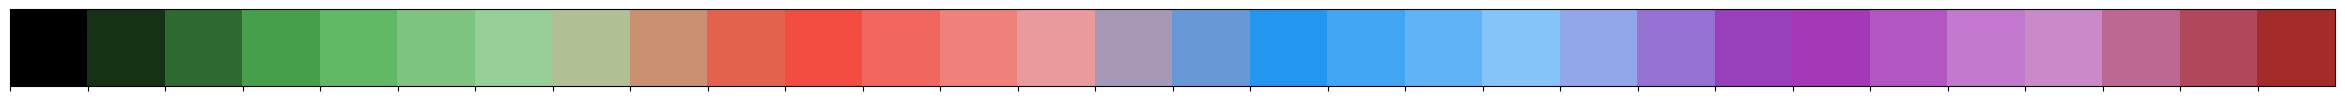

In [14]:
#sess_colors = ['black','#5AD141','#67E6D5','#1F665C','pink','#F054E0','#692161','yellow','#994C00'] # #19690A

sess_colors =  [
    "black","#4CAF50", "#A5D6A7",  # Condition 1 (Green)
    "#F44336", "#EF9A9A",  # Condition 2 (Red)
    "#2196F3", "#90CAF9",  # Condition 3 (Blue)
    "#9C27B0", "#CE93D8", "brown" ]  # Condition 4 (Purple)

plt_fill = sns.color_palette(sess_colors)
# Number of colors needed in the spectrum
num_colors = 30
plt_fill = sns.blend_palette(sess_colors, n_colors=num_colors, as_cmap=False)
sns.palplot(plt_fill)
plt.show()

In [15]:
contrast_labs = ['1%','2.5%','6.3%','15.8%','39.8%','100%']

In [16]:
offset_vals = [-0.05, 0.05]

In [17]:
SingleSessionBool = np.ones_like(sid, dtype=int)
for ss in np.unique(sid):
    idx = np.where(sid == ss)[0]
    if len(idx) != 2:
        print('only 1 session was completed')
        SingleSessionBool[idx] = 0
print(SingleSessionBool)

only 1 session was completed
only 1 session was completed
only 1 session was completed
only 1 session was completed
only 1 session was completed
only 1 session was completed
only 1 session was completed
only 1 session was completed
only 1 session was completed
only 1 session was completed
only 1 session was completed
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 1 1 0 1 1 1 1 1 1 0 0 0 0 0 1 1 0 0 0 1 1 1 1 1 1]


##### **Set Ylimit Bounds to plot CRF**

In [18]:
yLim_min = 0.2
yLim_max =  1.1 #3.5# 1.1 is default for local norm

In [19]:
offset_vals = [0.01, 0.05]
contrast_location = [1, 2.5, 6.3, 15.8, 39.8, 100]

In [20]:
print(np.sum((t == 1)&(session_mask == 1)))
print(np.sum((t == 2)&(session_mask == 1)))

26
26


### Import the Session Day Delay Array to plot across different session days

In [21]:
day_delay_dir = Path.home() / "Desktop" / "Visual_Plasticty_Pipeline" /"Pipeline Processed Outputs" / "SessionIndexKey"

os.chdir(day_delay_dir) # change old dir, to this dir
ddd = os.listdir(day_delay_dir) # list files in dir
print(f'Avilable Files to choose from: {len(ddd)}')
print(f'Files on hand: {ddd}') 
FileN = ddd[1]#d[1] # choose one            
file_path1 = os.path.join(day_delay_dir, FileN) # join paths and prep 2 load
print('Current WD:',file_path1) # does path exist ... ?
print('Does File #1 Exist?',os.path.exists(file_path1)) # yes or no
dddf = scipy.io.loadmat(file_path1) # RCA F1 File
print(dddf.keys())

group_day_delay = dddf['session_day_delay_groups'][0]

result = []
for val in group_day_delay:
    if np.isnan(val):
        result.append(np.nan)           # keep NaN as-is
    else:
        result.extend([val, val])       # repeat non-NaNs

ggd = np.array(result, dtype=float)
print(ggd.shape)

Avilable Files to choose from: 2
Files on hand: ['Clean_RCA_SessionOrder_Index_full_20250917_173007.mat', 'Clean_RCA_SessionOrder_Index_full_20250922_123330.mat']
Current WD: /Users/patricia.naomi/Desktop/Visual_Plasticty_Pipeline/Pipeline Processed Outputs/SessionIndexKey/Clean_RCA_SessionOrder_Index_full_20250922_123330.mat
Does File #1 Exist? True
dict_keys(['__header__', '__version__', '__globals__', 'SessionDatesOrder', 'Clean_SessionDatesOrder', 'session_day_delay_groups'])
(65,)


In [22]:
# test section
print(y.shape)
print(session_mask.shape)

test =  f1_data[(y == 1),:,:]
print(test.shape)

(exclude_NL_bool == 1)

(65,)
(65,)
(34, 2, 6)


array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False,  True,
        True, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True, False,  True,  True,
        True,  True,  True,  True, False, False, False, False, False,
        True,  True, False, False, False,  True,  True,  True,  True,
        True,  True])

## **Plot figures in log scale | Post-Exclusions**

In [23]:
dpiIn = 500
offset_vals_hemis = [-0.025, -0.05,0.025, 0.05]

#### **Effect of Attention per Hemifields**

N Subject per group: 26, 26, 26, 26


<ErrorbarContainer object of 3 artists>

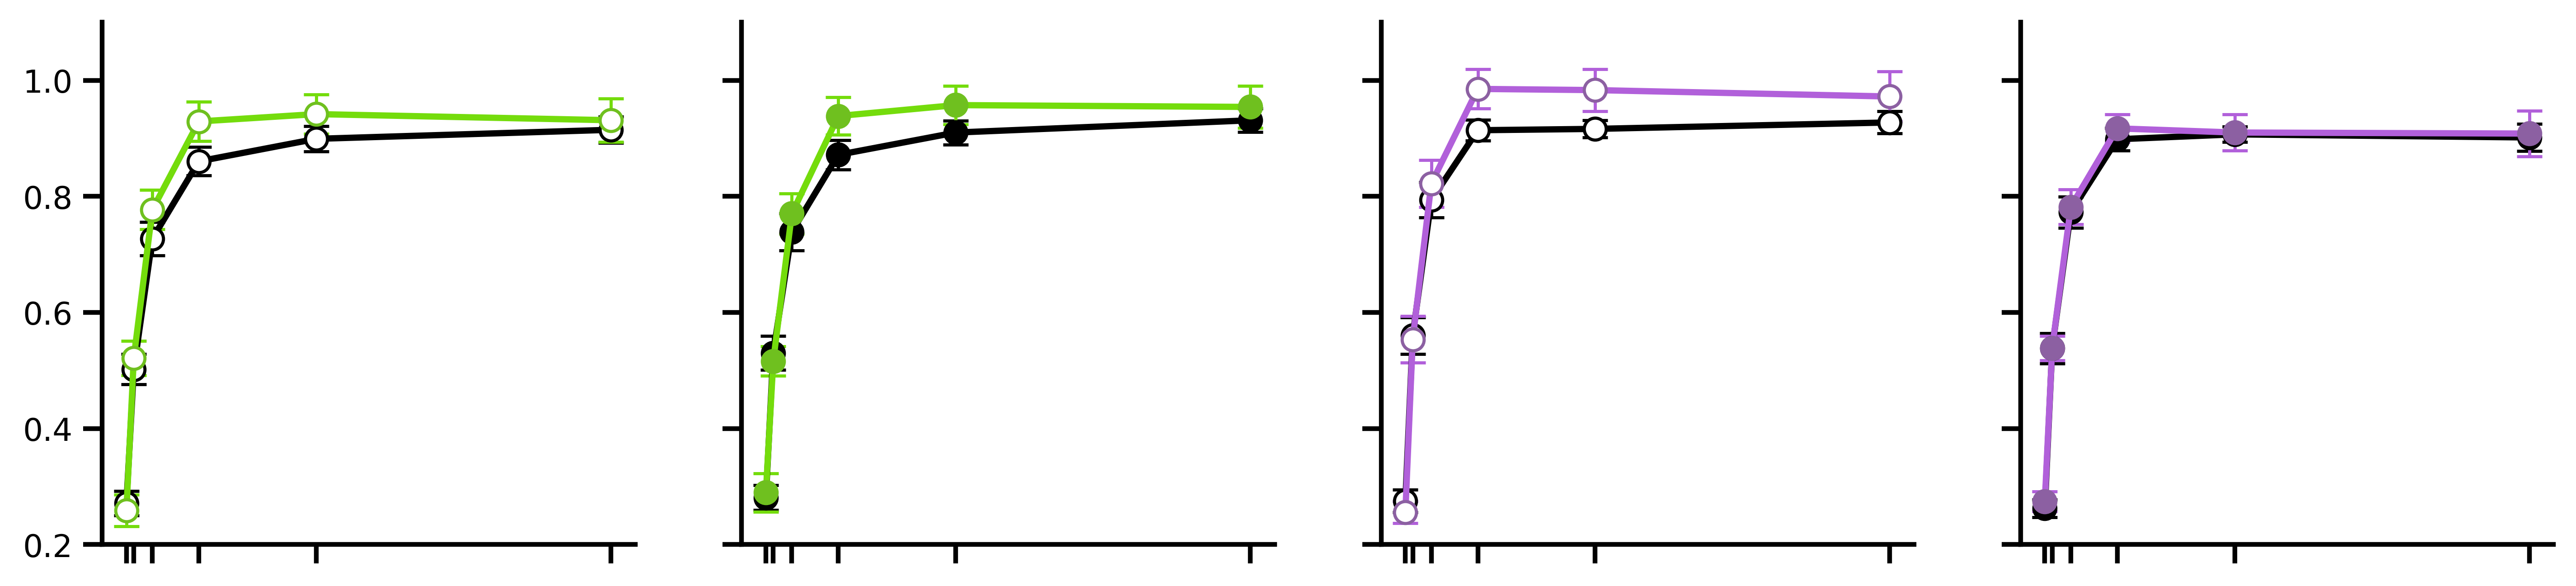

In [24]:
fig,axs = plt.subplots(1,4,figsize = ((14,3)), sharey = True,dpi=dpiIn)

# one plot [Left hemifield, attend left]
LHAttnL_Data1 = f1_data[(y == 1)&(session_mask == 1),:,:] # [Subj x timeBlocks x bin]
dataDims = np.shape(LHAttnL_Data1)
dataStandErrMeans1 = np.std(LHAttnL_Data1,axis = 0) / np.sqrt(int(dataDims[0])) # 2 x 6
dataMeans1 = np.nanmean(LHAttnL_Data1,axis = 0)

# one plot [right hemifield, attend left]
RHAttnL_Data2 = f2_data[(y == 1)&(session_mask == 1),:,:]
dataStandErrMeans2 = np.std(RHAttnL_Data2,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans2 = np.nanmean(RHAttnL_Data2,axis = 0)

# one plot [Left hemifield, attend right]
LHAttnR_Data1 = f1_data[(y == 0)&(session_mask == 1),:,:]
dataStandErrMeans3 = np.std(LHAttnR_Data1,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans3 = np.nanmean(LHAttnR_Data1,axis = 0)

# one plot [right hemifield, attend right]
RHAttnR_Data2 = f2_data[(y == 0)&(session_mask == 1),:,:]
dataStandErrMeans4 = np.std(RHAttnR_Data2,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans4 = np.nanmean(RHAttnR_Data2,axis = 0)

print(f"N Subject per group: {LHAttnL_Data1.shape[0]}, {RHAttnL_Data2.shape[0]}, {LHAttnR_Data1.shape[0]}, {RHAttnR_Data2.shape[0]}")

for x in range(4):
    # show only left + bottom
    axs[x].spines['right'].set_visible(False)
    axs[x].spines['top'].set_visible(False)

    # make the visible spines thicker
    for side in ('left', 'bottom'):
        axs[x].spines[side].set_linewidth(1.5)
    axs[x].set_xticks(contrast_location)
    axs[x].tick_params(width=1.5, length=6)
    axs[x].set_xticklabels([])       
    axs[x].set_ylim(yLim_min, yLim_max)

lineW = 2

axs[0].errorbar(contrast_location ,dataMeans1[0,:], yerr = dataStandErrMeans1[0,:], label = 'F1 pre', color = plt_fill[0],linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='white', markeredgecolor='black', markersize = 7)
axs[0].errorbar(contrast_location,dataMeans1[1,:], yerr = dataStandErrMeans1[1,:], label = 'F1 post', color = "#74DC0C",linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='white', markeredgecolor='#6FC01F', markersize = 7)

axs[1].errorbar(contrast_location ,dataMeans3[0,:], yerr = dataStandErrMeans3[0,:], label = 'F1 pre',  color = plt_fill[0],linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='black', markeredgecolor='black', markersize = 7)
axs[1].errorbar(contrast_location,dataMeans3[1,:], yerr = dataStandErrMeans3[1,:], label = 'F1 post', color = '#74DC0C',linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='#6FC01F', markeredgecolor='#6FC01F', markersize = 7)

axs[2].errorbar(contrast_location,dataMeans2[0,:], yerr = dataStandErrMeans2[0,:], label = 'F2 pre',  color = plt_fill[0],linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='white', markeredgecolor='black', markersize = 7)
axs[2].errorbar(contrast_location,dataMeans2[1,:], yerr = dataStandErrMeans2[1,:], label = 'F2 post', color = "#B160DA",linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='white', markeredgecolor='#8C60A2', markersize = 7)

axs[3].errorbar(contrast_location,dataMeans4[0,:], yerr = dataStandErrMeans4[0,:], label = 'F2 pre',capsize=4, elinewidth=1, color = plt_fill[0],linewidth = lineW,linestyle = '-',fmt = 'o', markerfacecolor='black', markeredgecolor='black', markersize = 7)
axs[3].errorbar(contrast_location,dataMeans4[1,:], yerr = dataStandErrMeans4[1,:], label = 'F2 post',capsize=4, elinewidth=1, color = '#B160DA',linewidth = lineW,linestyle = '-',fmt = 'o', markerfacecolor='#8C60A2', markeredgecolor='#8C60A2', markersize = 7)


#### **Effect of Session Day per Hemifields**

N Subject per group: 26, 26, 26, 26


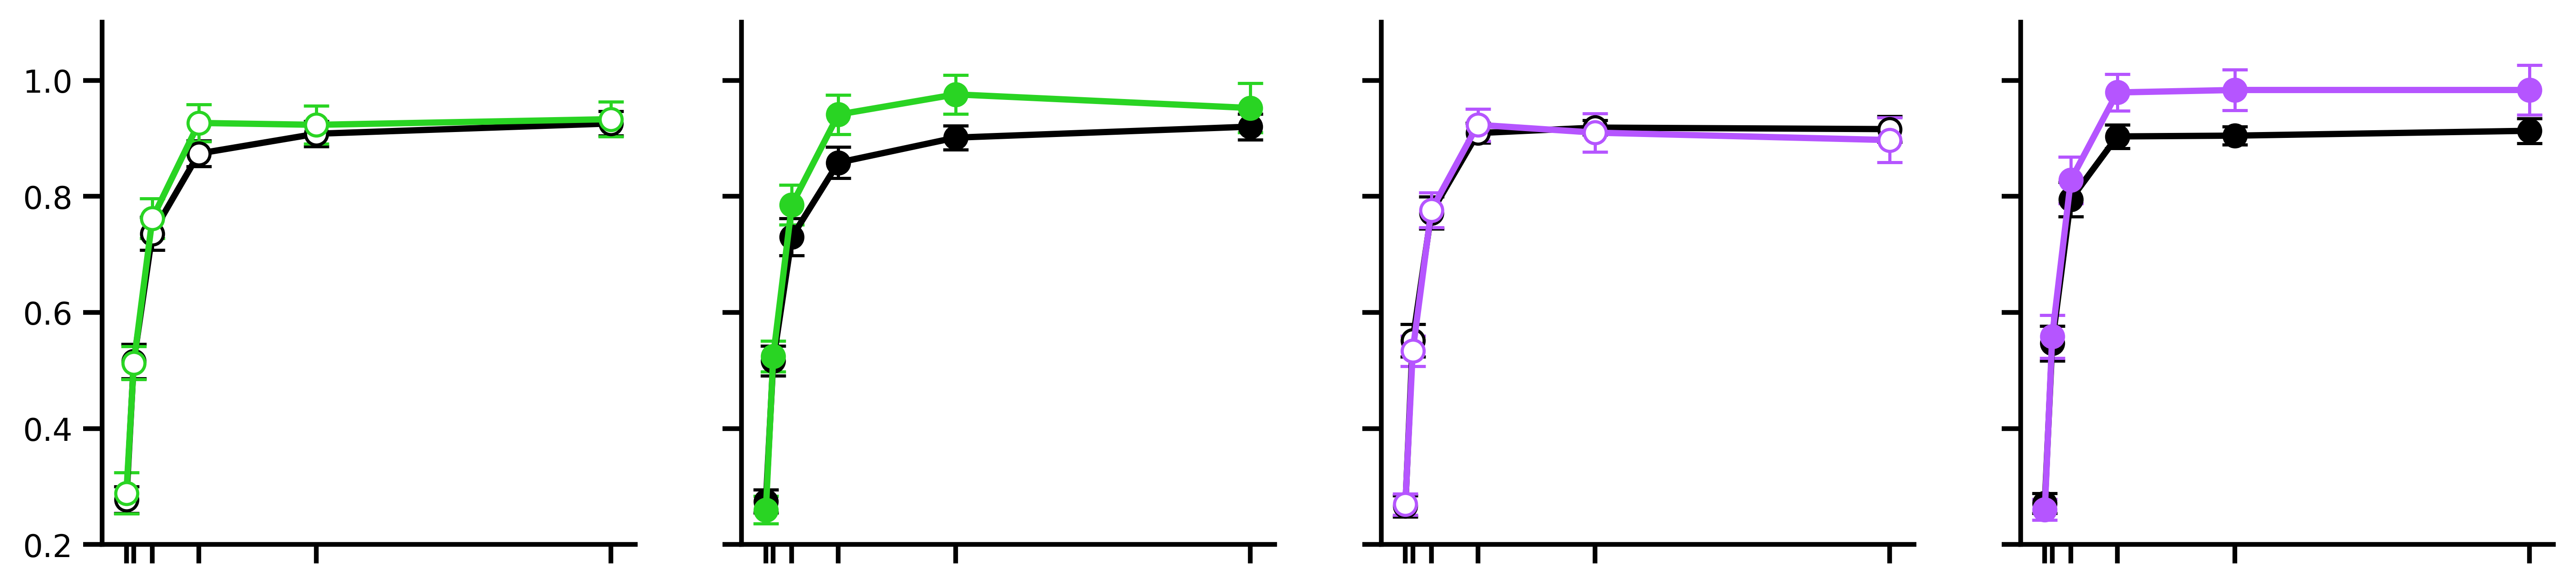

In [25]:
fig,axs = plt.subplots(1,4,figsize = ((14,3)), sharey = True,dpi=dpiIn)


Day1_LHData1 = f1_data[(t == 1)&(session_mask == 1),:,:]
dataDims = np.shape(Day1_LHData1)
dataStandErrMeans1 = np.std(Day1_LHData1,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans1 = np.nanmean(Day1_LHData1,axis = 0)


Day1_RHData2 = f2_data[(t == 1)&(session_mask == 1),:,:]
dataStandErrMeans2 = np.std(Day1_RHData2,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans2 = np.nanmean(Day1_RHData2,axis = 0)


Day2_LHData1 = f1_data[(t == 2)&(session_mask == 1),:,:]
dataStandErrMeans3 = np.std(Day2_LHData1,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans3 = np.nanmean(Day2_LHData1,axis = 0)


Day2_RHData2 = f2_data[(t == 2)&(session_mask == 1),:,:]
dataStandErrMeans4 = np.std(Day2_RHData2,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans4 = np.nanmean(Day2_RHData2,axis = 0)

axs[0].errorbar(contrast_location ,dataMeans1[0,:], yerr = dataStandErrMeans1[0,:], label = 'F1 pre', linestyle = '-', color = plt_fill[0],linewidth = lineW,capsize=4, elinewidth=1,fmt = 'o', markerfacecolor='white', markeredgecolor='black', markersize = 7)
axs[0].errorbar(contrast_location,dataMeans1[1,:], yerr = dataStandErrMeans1[1,:], label = 'F1 post', linestyle = '-', color = '#29D423',linewidth = lineW,capsize=4, elinewidth=1,fmt = 'o', markerfacecolor='white', markeredgecolor='#29D423', markersize = 7)

axs[2].errorbar(contrast_location,dataMeans2[0,:], yerr = dataStandErrMeans2[0,:], label = 'F2 pre',  linestyle = '-', color = plt_fill[0],linewidth = lineW,capsize=4, elinewidth=1,fmt = 'o', markerfacecolor='white', markeredgecolor='black', markersize = 7)
axs[2].errorbar(contrast_location,dataMeans2[1,:], yerr = dataStandErrMeans2[1,:], label = 'F2 post', linestyle = '-', color = '#b555ff',linewidth = lineW,capsize=4, elinewidth=1,fmt = 'o', markerfacecolor='white', markeredgecolor='#b555ff', markersize = 7)

axs[1].errorbar(contrast_location ,dataMeans3[0,:], yerr = dataStandErrMeans3[0,:], label = 'F1 pre',  linestyle = '-',  color = plt_fill[0],linewidth = lineW,capsize=4, elinewidth=1, fmt = 'o',markerfacecolor='black',     markeredgecolor='black',markersize = 7)
axs[1].errorbar(contrast_location,dataMeans3[1,:], yerr = dataStandErrMeans3[1,:], label = 'F1 post', linestyle = '-', color = '#29D423',linewidth = lineW,capsize=4, elinewidth=1, fmt = 'o', markerfacecolor='#29D423', markeredgecolor='#29D423', markersize = 7)

axs[3].errorbar(contrast_location,dataMeans4[0,:], yerr = dataStandErrMeans4[0,:], label = 'F2 pre',linestyle = '-', color = plt_fill[0],linewidth = lineW,capsize=4, elinewidth=1, fmt = 'o',markerfacecolor='black',     markeredgecolor='black',markersize = 7)
axs[3].errorbar(contrast_location,dataMeans4[1,:], yerr = dataStandErrMeans4[1,:], label = 'F2 post',linestyle = '-', color = '#b555ff',linewidth = lineW,capsize=4, elinewidth=1, fmt = 'o',markerfacecolor='#b555ff',     markeredgecolor='#b555ff',markersize = 7)

print(f"N Subject per group: {Day1_LHData1.shape[0]}, {Day1_RHData2.shape[0]}, {Day2_LHData1.shape[0]}, {Day2_RHData2.shape[0]}")

for x in range(4):
    # show only left + bottom
    axs[x].spines['right'].set_visible(False)
    axs[x].spines['top'].set_visible(False)

    # make the visible spines thicker
    for side in ('left', 'bottom'):
        axs[x].spines[side].set_linewidth(1.5)
    axs[x].set_xticks(contrast_location)
    axs[x].tick_params(width=1.5, length=6)
    axs[x].set_xticklabels([])       
    axs[x].set_ylim(yLim_min, yLim_max)

#### **Effect of Session Day x Attention Interaction per Hemifields | Day 1 AttnL, Day 2 AttnR**

(13, 2, 6)
(13, 2, 6)
N Subject per group: 13, 13, 13, 13


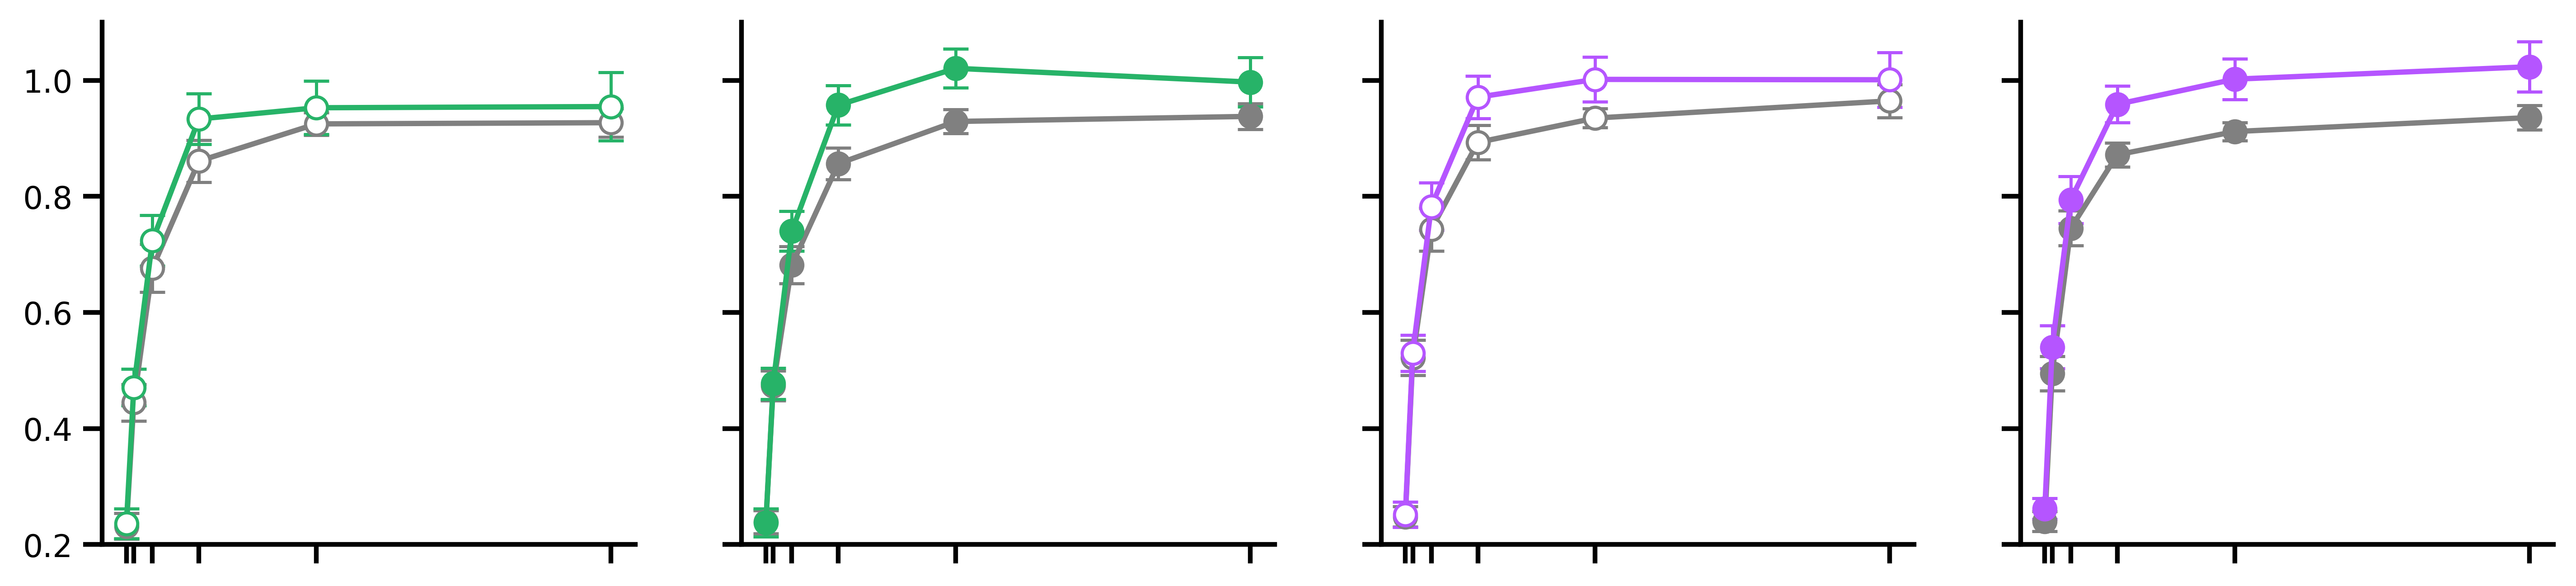

In [26]:
dpiIn = 500

fig,axs = plt.subplots(1,4,figsize = ((14,3)), sharey = True,dpi=dpiIn)


Day1_AL_LH = f1_data[(exclude_NL_bool == 1)&(y == 1)&(t == 1)&(session_mask == 1),:,:] # [attend left, 1st session, left hemifield]
print(Day1_AL_LH.shape)
dataDims = np.shape(Day1_AL_LH)
dataStandErrMeans1 = np.std(Day1_AL_LH,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans1 = np.nanmean(Day1_AL_LH,axis = 0)

Day1_AL_RH = f2_data[(exclude_NL_bool == 1)&(y == 1)&(t == 1)&(session_mask == 1),:,:] # [attend left, 1st session, right hemifield]
dataStandErrMeans2 = np.std(Day1_AL_RH,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans2 = np.nanmean(Day1_AL_RH,axis = 0)

Day2_AR_LH = f1_data[(exclude_NL_bool == 1)&(y == 0)&(t == 2)&(session_mask == 1),:,:] # [attend right, 2nd session, left hemifield]
dataStandErrMeans1 = np.std(Day2_AR_LH,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans3 = np.nanmean(Day2_AR_LH,axis = 0)

Day2_AR_RH = f2_data[(exclude_NL_bool == 1)&(y == 0)&(t == 2)&(session_mask == 1),:,:]
print(Day2_AR_RH.shape)
dataStandErrMeans2 = np.std(Day2_AR_RH,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans4 = np.nanmean(Day2_AR_RH,axis = 0)

lineW = 1.7

axs[0].errorbar(contrast_location ,dataMeans1[0,:], yerr = dataStandErrMeans1[0,:], label = 'F1 pre', color = 'gray',linewidth = lineW,capsize=4, elinewidth=1, linestyle = '-',fmt = 'o', markerfacecolor='white', markeredgecolor='gray', markersize = 7)
axs[0].errorbar(contrast_location,dataMeans1[1,:], yerr = dataStandErrMeans1[1,:], label = 'F1 post', color = '#27B368',linewidth = lineW,capsize=4, elinewidth=1, linestyle = '-',fmt = 'o', markerfacecolor='white', markeredgecolor='#27B368', markersize = 7)

axs[2].errorbar(contrast_location,dataMeans2[0,:], yerr = dataStandErrMeans2[0,:], label = 'F2 pre',  color = 'gray',linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='white', markeredgecolor='gray', markersize = 7)
axs[2].errorbar(contrast_location,dataMeans2[1,:], yerr = dataStandErrMeans2[1,:], label = 'F2 post', color = '#b555ff',linewidth = lineW,capsize=4, elinewidth=1, linestyle = '-',fmt = 'o', markerfacecolor='white', markeredgecolor='#b555ff', markersize = 7)

axs[1].errorbar(contrast_location ,dataMeans3[0,:], yerr = dataStandErrMeans3[0,:], label = 'F1 pre',  color = 'gray',linewidth = lineW,capsize=4, elinewidth=1, linestyle = '-',fmt = 'o', markerfacecolor='gray', markeredgecolor='gray', markersize = 7)
axs[1].errorbar(contrast_location,dataMeans3[1,:], yerr = dataStandErrMeans3[1,:], label = 'F1 post', color = '#27B368',linewidth = lineW,capsize=4, elinewidth=1, linestyle = '-',fmt = 'o', markerfacecolor='#27B368', markeredgecolor='#27B368', markersize = 7)

axs[3].errorbar(contrast_location,dataMeans4[0,:], yerr = dataStandErrMeans4[0,:], label = 'F2 pre', color = 'gray',linewidth = lineW,capsize=4, elinewidth=1, linestyle = '-',fmt = 'o', markerfacecolor='gray', markeredgecolor='gray', markersize = 7)
axs[3].errorbar(contrast_location,dataMeans4[1,:], yerr = dataStandErrMeans4[1,:], label = 'F2 post', color = '#b555ff',linewidth = lineW,capsize=4, elinewidth=1, linestyle = '-',fmt = 'o', markerfacecolor='#b555ff', markeredgecolor='#b555ff', markersize = 7)

print(f"N Subject per group: {Day1_AL_LH.shape[0]}, {Day1_AL_RH.shape[0]}, {Day2_AR_LH.shape[0]}, {Day2_AR_RH.shape[0]}")

for x in range(4):
    # show only left + bottom
    axs[x].spines['right'].set_visible(False)
    axs[x].spines['top'].set_visible(False)

    # make the visible spines thicker
    for side in ('left', 'bottom'):
        axs[x].spines[side].set_linewidth(1.5)
    axs[x].set_xticks(contrast_location)
    axs[x].tick_params(width=1.5, length=6)
    axs[x].set_xticklabels([])       
    axs[x].set_ylim(yLim_min, yLim_max)
    axs[x].set_ylim(yLim_min, yLim_max)

#### **Effect of Session Day x Attention Interaction per Hemifields | Day 1 AttnR, Day 2 AttnL**

(13, 2, 6)
(13, 2, 6)
(13, 2, 6)
N Subject per group: 13, 13, 13, 13


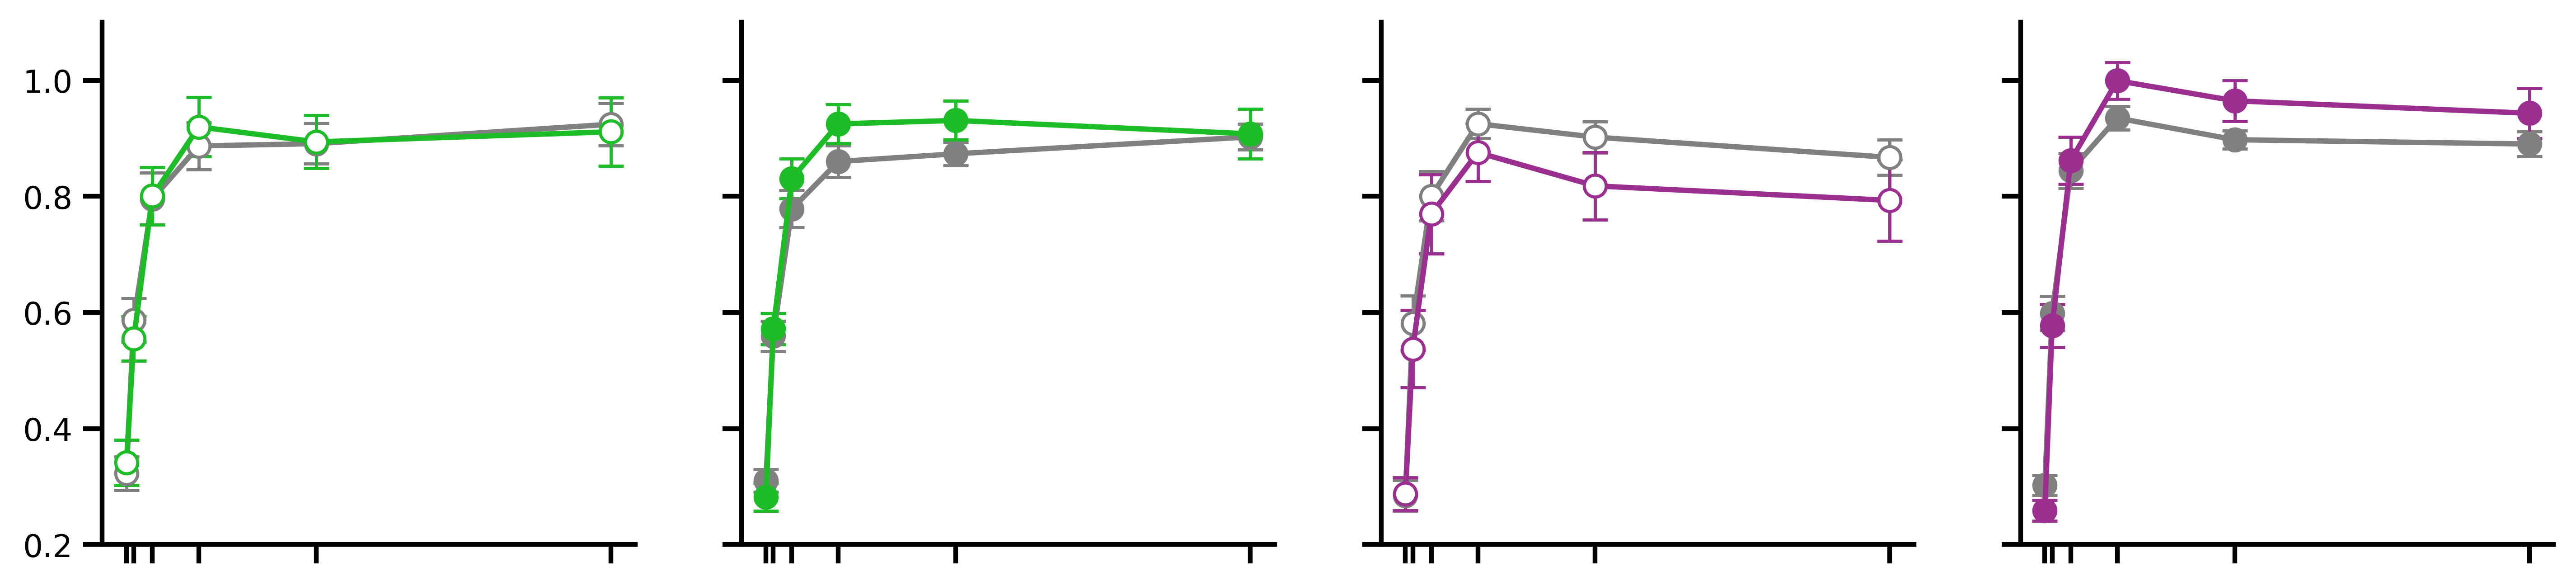

In [27]:
dpiIn = 500

fig,axs = plt.subplots(1,4,figsize = ((14,3)), sharey = True,dpi=dpiIn)

Day1_AR_LH = f1_data[(exclude_NL_bool == 1)&(y == 0)&(t == 1)&(session_mask == 1),:,:]
print(Day1_AR_LH.shape)
print(Day1_AR_LH.shape)
dataDims = np.shape(Day1_AR_LH)
dataStandErrMeans1 = np.std(Day1_AR_LH,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans1 = np.nanmean(Day1_AR_LH,axis = 0)

Day1_AR_RH = f2_data[(exclude_NL_bool == 1)&(y == 0)&(t == 1)&(session_mask == 1),:,:]
dataStandErrMeans2 = np.std(Day1_AR_RH,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans2 = np.nanmean(Day1_AR_RH,axis = 0)

Day2_AL_LH = f1_data[(exclude_NL_bool == 1)&(y == 1)&(t == 2)&(session_mask == 1),:,:]
dataDims = np.shape(Day2_AL_LH)
dataStandErrMeans1 = np.std(Day2_AL_LH,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans3 = np.nanmean(Day2_AL_LH,axis = 0)

Day2_AL_RH = f2_data[(exclude_NL_bool == 1)&(y == 1)&(t == 2)&(session_mask == 1),:,:]
print(Day2_AL_RH.shape)
dataStandErrMeans2 = np.std(Day2_AL_RH,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans4 = np.nanmean(Day2_AL_RH,axis = 0)

lineW = 1.7

axs[0].errorbar(contrast_location ,dataMeans1[0,:], yerr = dataStandErrMeans1[0,:], label = 'F1 pre', color = 'gray',linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='white', markeredgecolor='gray', markersize = 7)
axs[0].errorbar(contrast_location,dataMeans1[1,:], yerr = dataStandErrMeans1[1,:], label = 'F1 post', color = '#1DBD28',linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='white', markeredgecolor='#1DBD28', markersize = 7)

axs[2].errorbar(contrast_location,dataMeans2[0,:], yerr = dataStandErrMeans2[0,:], label = 'F2 pre',  color = 'gray',linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='white', markeredgecolor='gray', markersize = 7)
axs[2].errorbar(contrast_location,dataMeans2[1,:], yerr = dataStandErrMeans2[1,:], label = 'F2 post', color = '#9A2F8F',linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='white', markeredgecolor='#9A2F8F', markersize = 7)

axs[1].errorbar( contrast_location,dataMeans3[0,:], yerr = dataStandErrMeans3[0,:], label = 'F1 pre',  color = 'gray',linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='gray', markeredgecolor='gray', markersize = 7)
axs[1].errorbar(contrast_location,dataMeans3[1,:], yerr = dataStandErrMeans3[1,:], label = 'F1 post', color = '#1DBD28',linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='#1DBD28', markeredgecolor='#1DBD28', markersize = 7)

axs[3].errorbar(contrast_location,dataMeans4[0,:], yerr = dataStandErrMeans4[0,:], label = 'F2 pre', color = 'gray',linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='gray', markeredgecolor='gray', markersize = 7)
axs[3].errorbar(contrast_location,dataMeans4[1,:], yerr = dataStandErrMeans4[1,:], label = 'F2 post', color = '#9A2F8F',linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='#9A2F8F', markeredgecolor='#9A2F8F', markersize = 7)

print(f"N Subject per group: {Day1_AR_LH.shape[0]}, {Day1_AR_RH.shape[0]}, {Day2_AL_LH.shape[0]}, {Day2_AL_RH.shape[0]}")

for x in range(4):
    # show only left + bottom
    axs[x].spines['right'].set_visible(False)
    axs[x].spines['top'].set_visible(False)

    # make the visible spines thicker
    for side in ('left', 'bottom'):
        axs[x].spines[side].set_linewidth(1.5)
    axs[x].set_xticks(contrast_location)
    axs[x].tick_params(width=1.5, length=6)
    axs[x].set_xticklabels([])       
    axs[x].set_ylim(yLim_min, yLim_max)
    axs[x].set_ylim(yLim_min, yLim_max)

#### **Average Pre/Post CRF per hemifield**

N Subject per group: 52, 52


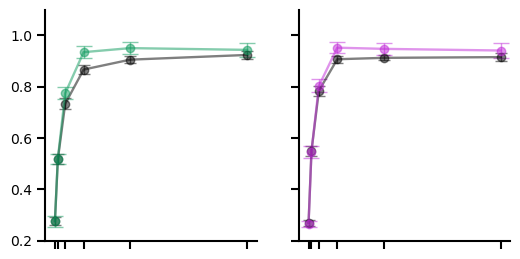

In [28]:
dpiIn = 100

fig,axs = plt.subplots(1,2,figsize = ((6,3)), sharey = True,dpi=dpiIn)
lineW = 1.7

#########################

left_hemifield_resposes = f1_data[(exclude_NL_bool == 1)&(session_mask == 1),:,:]
dataDims = np.shape(left_hemifield_resposes)
dataStandErrMeans1 = np.std(left_hemifield_resposes,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans1 = np.nanmean(left_hemifield_resposes,axis = 0)

right_hemifield_resposes = f2_data[(exclude_NL_bool == 1)&(session_mask == 1),:,:]
dataStandErrMeans2 = np.std(right_hemifield_resposes,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans2 = np.nanmean(right_hemifield_resposes,axis = 0)

#########################|

axs[0].errorbar(contrast_location ,dataMeans1[0,:], yerr = dataStandErrMeans1[0,:], label = 'F1 pre', color = 'black',linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='black', markeredgecolor='black', markersize = 6, alpha = 0.5)
axs[0].errorbar(contrast_location,dataMeans1[1,:], yerr = dataStandErrMeans1[1,:], label = 'F1 post', color = "#0D9A5DF5",linewidth = lineW,capsize=6, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='#0D9A5DF5', markeredgecolor="#0D9A5DF5", markersize = 6, alpha = 0.5)

axs[1].errorbar(contrast_location,dataMeans2[0,:], yerr = dataStandErrMeans2[0,:], label = 'F2 pre',  color = 'black',linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='black', markeredgecolor='black', markersize = 6, alpha = 0.5)
axs[1].errorbar(contrast_location,dataMeans2[1,:], yerr = dataStandErrMeans2[1,:], label = 'F2 post', color = "#C12AD8",linewidth = lineW,capsize=6, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='#C12AD8', markeredgecolor="#C12AD8", markersize = 6, alpha = 0.5)

#########################
print(f"N Subject per group: {left_hemifield_resposes.shape[0]}, {right_hemifield_resposes.shape[0]}")
#########################
for x in range(2):
    # show only left + bottom
    axs[x].spines['right'].set_visible(False)
    axs[x].spines['top'].set_visible(False)

    # make the visible spines thicker
    for side in ('left', 'bottom'):
        axs[x].spines[side].set_linewidth(1.5)
    axs[x].set_xticks(contrast_location)
    axs[x].tick_params(width=1.5, length=6)
    axs[x].set_xticklabels([])       
    axs[x].set_ylim(yLim_min, yLim_max)


0
(13, 2, 6)
(13, 2, 6)
1
(8, 2, 6)
(8, 2, 6)
2
(5, 2, 6)
(5, 2, 6)


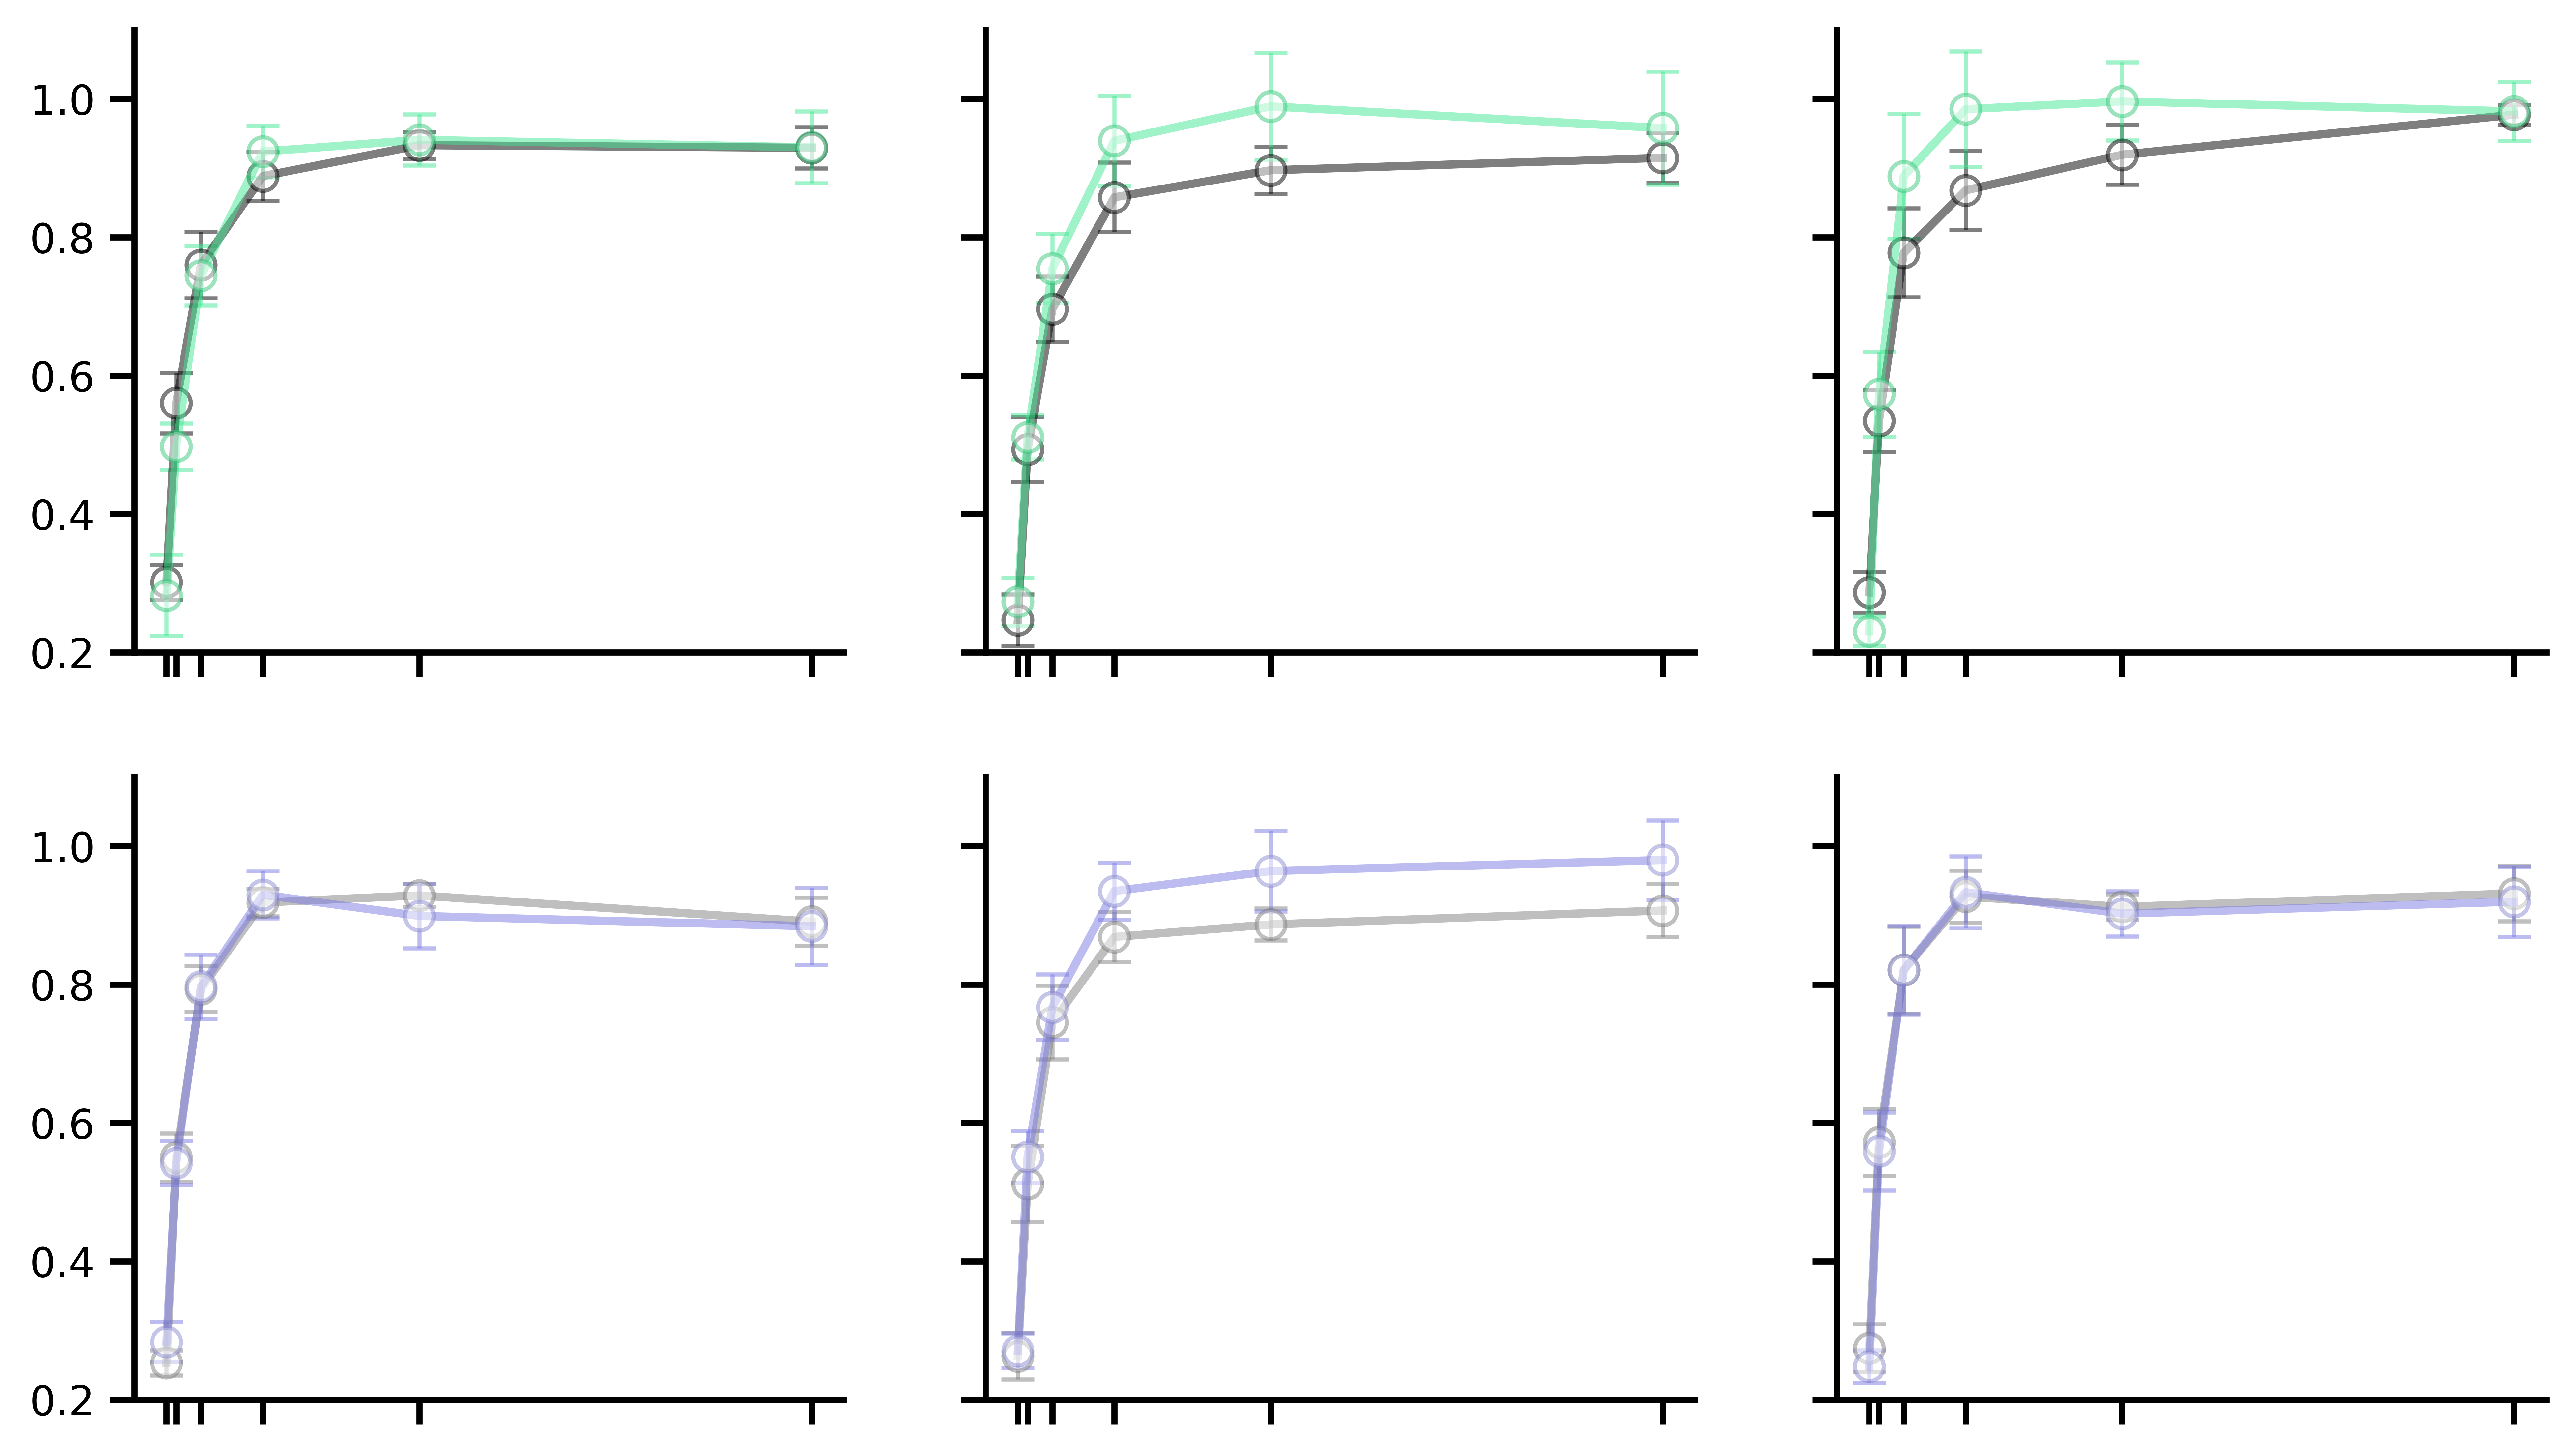

In [29]:
dpiIn = 900
lineW = 2
offset_vals_hemis = [-0.025, -0.05,0.025, 0.05]

fig,axs = plt.subplots(2,3,figsize = ((10.5,6)), sharey = True,dpi=dpiIn)

for delay_g in range(3):
    print(delay_g)
    # one plot [Left hemifield]
    LH_Data = f1_data[(exclude_NL_bool == 1)&(ggd == delay_g+1)&(session_mask == 1)&(z == 2),:,:] # [Subj x timeBlocks x bin]
    dataDims = np.shape(LH_Data)
    print(dataDims)
    dataStandErrMeans1 = np.std(LH_Data,axis = 0) / np.sqrt(int(dataDims[0])) # 2 x 6
    dataMeans1 = np.nanmean(LH_Data,axis = 0)

    axs[0,delay_g].errorbar(contrast_location ,dataMeans1[0,:], yerr = dataStandErrMeans1[0,:], label = 'F1 pre', color = plt_fill[0],linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='white', markeredgecolor='black', markersize = 7, alpha = 0.5)
    axs[0,delay_g].errorbar(contrast_location,dataMeans1[1,:], yerr = dataStandErrMeans1[1,:], label = 'F1 post', color = "#42E892",linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='white', markeredgecolor="#36C87C", markersize = 7, alpha = 0.5)


    # one plot [right hemifield]
    RH_Data = f2_data[(exclude_NL_bool == 1)&(ggd == delay_g+1)&(session_mask == 1)&(z == 2),:,:] # [Subj x timeBlocks x bin]
    dataDims = np.shape(RH_Data)
    print(dataDims)
    dataStandErrMeans2 = np.std(RH_Data,axis = 0) / np.sqrt(int(dataDims[0])) # 2 x 6
    dataMeans2 = np.nanmean(RH_Data,axis = 0)

    axs[1,delay_g].errorbar(contrast_location ,dataMeans2[0,:], yerr = dataStandErrMeans2[0,:], label = 'F1 pre', color = 'gray',linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='white', markeredgecolor='gray', markersize = 7, alpha = 0.5)
    axs[1,delay_g].errorbar(contrast_location,dataMeans2[1,:], yerr = dataStandErrMeans2[1,:], label = 'F1 post', color = "#7A7AE4",linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='white', markeredgecolor="#8C8CD0", markersize = 7, alpha = 0.5)


    for x in range(3):
        # show only left + bottom
        axs[0,delay_g].spines['right'].set_visible(False)
        axs[0,delay_g].spines['top'].set_visible(False)

        axs[1,delay_g].spines['right'].set_visible(False)
        axs[1,delay_g].spines['top'].set_visible(False)

        axs[0,delay_g].tick_params(width=1.5, length=6)
        axs[0,delay_g].set_xticklabels([])  
        axs[1,delay_g].tick_params(width=1.5, length=6)
        axs[1,delay_g].set_xticklabels([])

        # make the visible spines thicker
        for side in ('left', 'bottom'):
            axs[0,delay_g].spines[side].set_linewidth(1.5)
            axs[1,delay_g].spines[side].set_linewidth(1.5)

        axs[1,delay_g].set_xticks(contrast_location)
        axs[0,delay_g].set_xticks(contrast_location)
        axs[0,delay_g].set_ylim(yLim_min, yLim_max)
        axs[1,delay_g].set_ylim(yLim_min, yLim_max)

#### Sanity Check for Figures

(21, 2, 6)
(14, 2, 6)
N Subject per group: 21, 21, 14, 14


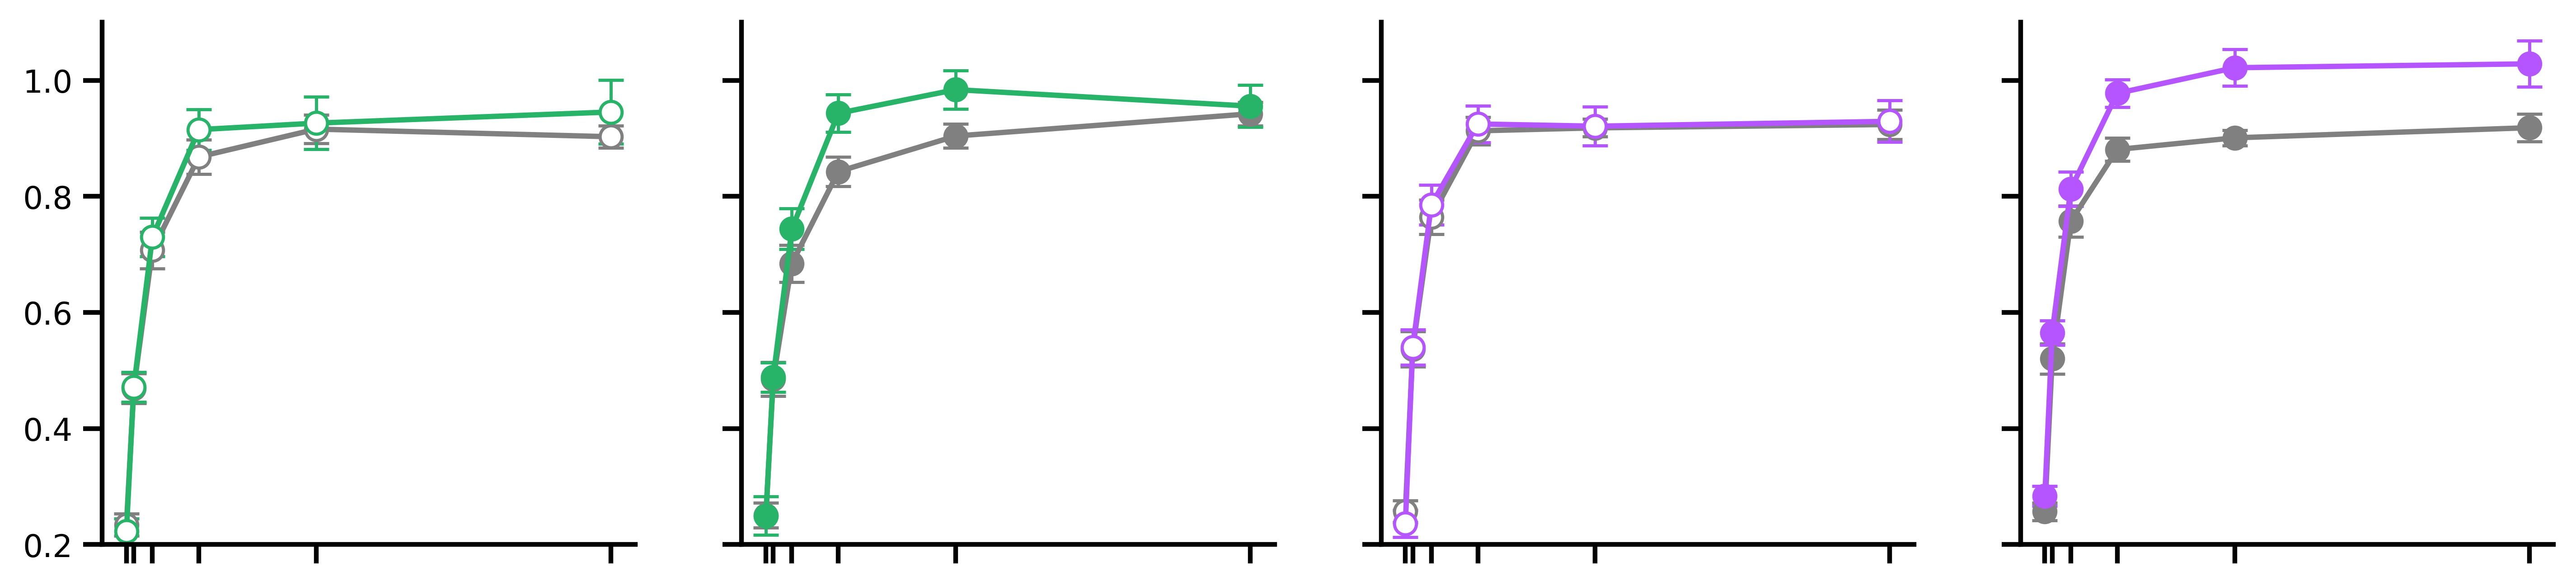

In [36]:
dpiIn = 500

fig,axs = plt.subplots(1,4,figsize = ((14,3)), sharey = True,dpi=dpiIn)


Day1_AL_LH = f1_data[(y == 1)&(t == 1),:,:] # [attend left, 1st session, left hemifield]
print(Day1_AL_LH.shape)
dataDims = np.shape(Day1_AL_LH)
dataStandErrMeans1 = np.std(Day1_AL_LH,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans1 = np.nanmean(Day1_AL_LH,axis = 0)

Day1_AL_RH = f2_data[(y == 1)&(t == 1),:,:] # [attend left, 1st session, right hemifield]
dataStandErrMeans2 = np.std(Day1_AL_RH,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans2 = np.nanmean(Day1_AL_RH,axis = 0)

Day2_AR_LH = f1_data[(y == 0)&(t == 2),:,:] # [attend right, 2nd session, left hemifield]
dataStandErrMeans1 = np.std(Day2_AR_LH,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans3 = np.nanmean(Day2_AR_LH,axis = 0)

Day2_AR_RH = f2_data[(y == 0)&(t == 2),:,:]
print(Day2_AR_RH.shape)
dataStandErrMeans2 = np.std(Day2_AR_RH,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans4 = np.nanmean(Day2_AR_RH,axis = 0)

lineW = 1.7

axs[0].errorbar(contrast_location ,dataMeans1[0,:], yerr = dataStandErrMeans1[0,:], label = 'F1 pre', color = 'gray',linewidth = lineW,capsize=4, elinewidth=1, linestyle = '-',fmt = 'o', markerfacecolor='white', markeredgecolor='gray', markersize = 7)
axs[0].errorbar(contrast_location,dataMeans1[1,:], yerr = dataStandErrMeans1[1,:], label = 'F1 post', color = '#27B368',linewidth = lineW,capsize=4, elinewidth=1, linestyle = '-',fmt = 'o', markerfacecolor='white', markeredgecolor='#27B368', markersize = 7)

axs[2].errorbar(contrast_location,dataMeans2[0,:], yerr = dataStandErrMeans2[0,:], label = 'F2 pre',  color = 'gray',linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='white', markeredgecolor='gray', markersize = 7)
axs[2].errorbar(contrast_location,dataMeans2[1,:], yerr = dataStandErrMeans2[1,:], label = 'F2 post', color = '#b555ff',linewidth = lineW,capsize=4, elinewidth=1, linestyle = '-',fmt = 'o', markerfacecolor='white', markeredgecolor='#b555ff', markersize = 7)

axs[1].errorbar(contrast_location ,dataMeans3[0,:], yerr = dataStandErrMeans3[0,:], label = 'F1 pre',  color = 'gray',linewidth = lineW,capsize=4, elinewidth=1, linestyle = '-',fmt = 'o', markerfacecolor='gray', markeredgecolor='gray', markersize = 7)
axs[1].errorbar(contrast_location,dataMeans3[1,:], yerr = dataStandErrMeans3[1,:], label = 'F1 post', color = '#27B368',linewidth = lineW,capsize=4, elinewidth=1, linestyle = '-',fmt = 'o', markerfacecolor='#27B368', markeredgecolor='#27B368', markersize = 7)

axs[3].errorbar(contrast_location,dataMeans4[0,:], yerr = dataStandErrMeans4[0,:], label = 'F2 pre', color = 'gray',linewidth = lineW,capsize=4, elinewidth=1, linestyle = '-',fmt = 'o', markerfacecolor='gray', markeredgecolor='gray', markersize = 7)
axs[3].errorbar(contrast_location,dataMeans4[1,:], yerr = dataStandErrMeans4[1,:], label = 'F2 post', color = '#b555ff',linewidth = lineW,capsize=4, elinewidth=1, linestyle = '-',fmt = 'o', markerfacecolor='#b555ff', markeredgecolor='#b555ff', markersize = 7)

print(f"N Subject per group: {Day1_AL_LH.shape[0]}, {Day1_AL_RH.shape[0]}, {Day2_AR_LH.shape[0]}, {Day2_AR_RH.shape[0]}")

for x in range(4):
    # show only left + bottom
    axs[x].spines['right'].set_visible(False)
    axs[x].spines['top'].set_visible(False)

    # make the visible spines thicker
    for side in ('left', 'bottom'):
        axs[x].spines[side].set_linewidth(1.5)
    axs[x].set_xticks(contrast_location)
    axs[x].tick_params(width=1.5, length=6)
    axs[x].set_xticklabels([])       
    axs[x].set_ylim(yLim_min, yLim_max)
    axs[x].set_ylim(yLim_min, yLim_max)

(17, 2, 6)
(17, 2, 6)
(13, 2, 6)
N Subject per group: 17, 17, 13, 13


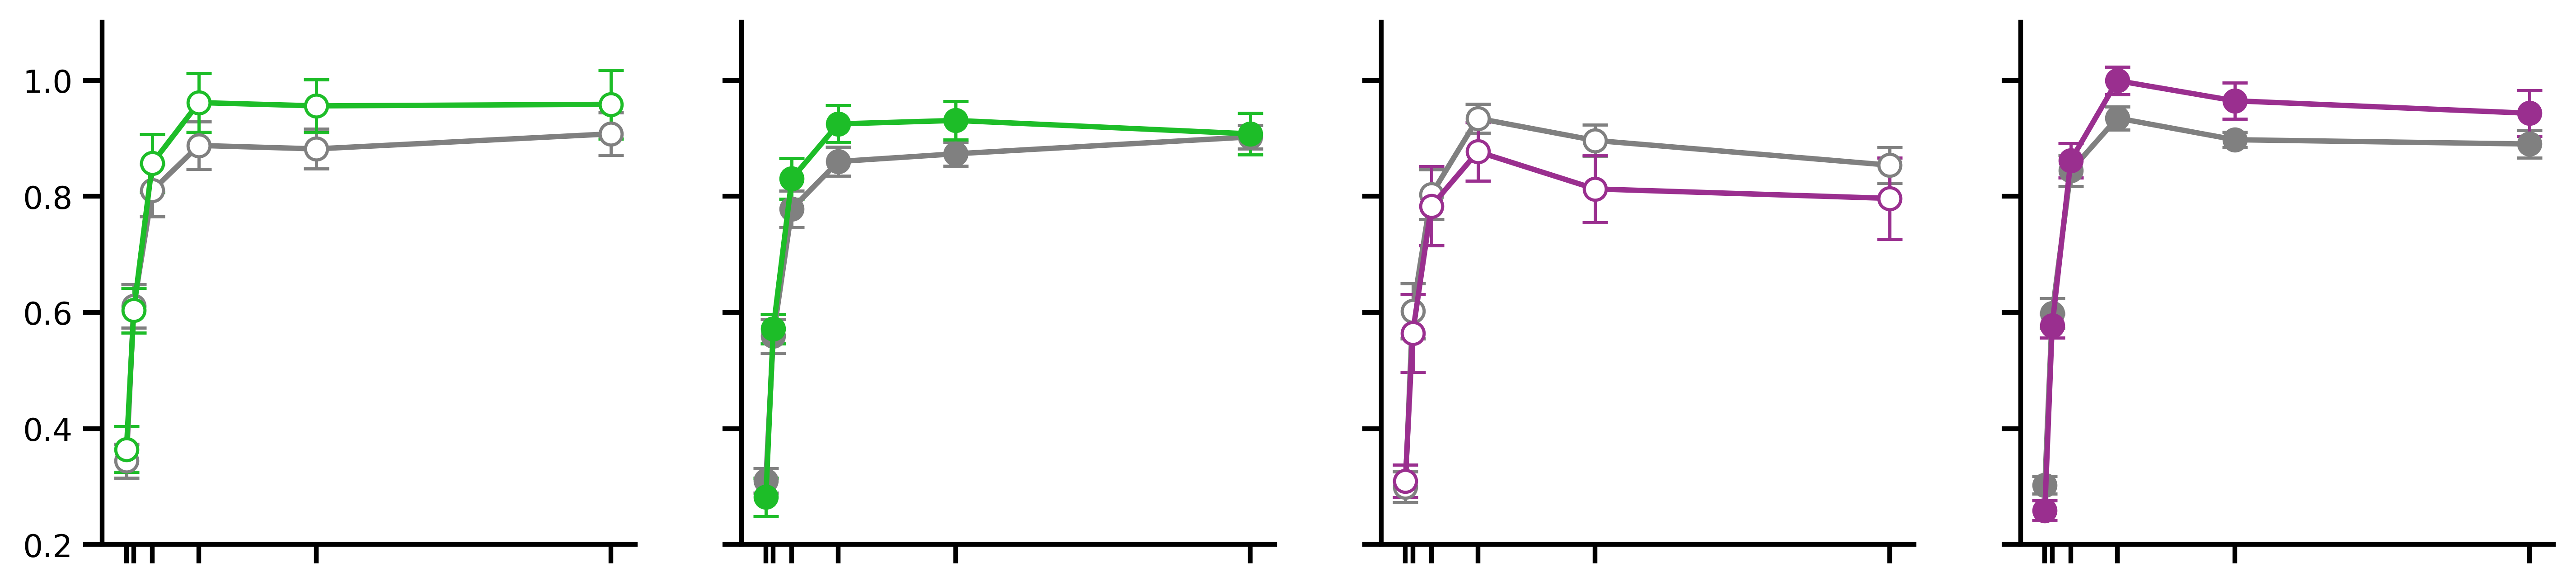

In [38]:
dpiIn = 500

fig,axs = plt.subplots(1,4,figsize = ((14,3)), sharey = True,dpi=dpiIn)

Day1_AR_LH = f1_data[(y == 0)&(t == 1),:,:]
print(Day1_AR_LH.shape)
print(Day1_AR_LH.shape)
dataDims = np.shape(Day1_AR_LH)
dataStandErrMeans1 = np.std(Day1_AR_LH,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans1 = np.nanmean(Day1_AR_LH,axis = 0)

Day1_AR_RH = f2_data[(y == 0)&(t == 1),:,:]
dataStandErrMeans2 = np.std(Day1_AR_RH,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans2 = np.nanmean(Day1_AR_RH,axis = 0)

Day2_AL_LH = f1_data[(y == 1)&(t == 2),:,:]
dataDims = np.shape(Day2_AL_LH)
dataStandErrMeans1 = np.std(Day2_AL_LH,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans3 = np.nanmean(Day2_AL_LH,axis = 0)

Day2_AL_RH = f2_data[(y == 1)&(t == 2),:,:]
print(Day2_AL_RH.shape)
dataStandErrMeans2 = np.std(Day2_AL_RH,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans4 = np.nanmean(Day2_AL_RH,axis = 0)

lineW = 1.7

axs[0].errorbar(contrast_location ,dataMeans1[0,:], yerr = dataStandErrMeans1[0,:], label = 'F1 pre', color = 'gray',linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='white', markeredgecolor='gray', markersize = 7)
axs[0].errorbar(contrast_location,dataMeans1[1,:], yerr = dataStandErrMeans1[1,:], label = 'F1 post', color = '#1DBD28',linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='white', markeredgecolor='#1DBD28', markersize = 7)

axs[2].errorbar(contrast_location,dataMeans2[0,:], yerr = dataStandErrMeans2[0,:], label = 'F2 pre',  color = 'gray',linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='white', markeredgecolor='gray', markersize = 7)
axs[2].errorbar(contrast_location,dataMeans2[1,:], yerr = dataStandErrMeans2[1,:], label = 'F2 post', color = '#9A2F8F',linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='white', markeredgecolor='#9A2F8F', markersize = 7)

axs[1].errorbar( contrast_location,dataMeans3[0,:], yerr = dataStandErrMeans3[0,:], label = 'F1 pre',  color = 'gray',linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='gray', markeredgecolor='gray', markersize = 7)
axs[1].errorbar(contrast_location,dataMeans3[1,:], yerr = dataStandErrMeans3[1,:], label = 'F1 post', color = '#1DBD28',linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='#1DBD28', markeredgecolor='#1DBD28', markersize = 7)

axs[3].errorbar(contrast_location,dataMeans4[0,:], yerr = dataStandErrMeans4[0,:], label = 'F2 pre', color = 'gray',linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='gray', markeredgecolor='gray', markersize = 7)
axs[3].errorbar(contrast_location,dataMeans4[1,:], yerr = dataStandErrMeans4[1,:], label = 'F2 post', color = '#9A2F8F',linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='#9A2F8F', markeredgecolor='#9A2F8F', markersize = 7)

print(f"N Subject per group: {Day1_AR_LH.shape[0]}, {Day1_AR_RH.shape[0]}, {Day2_AL_LH.shape[0]}, {Day2_AL_RH.shape[0]}")

for x in range(4):
    # show only left + bottom
    axs[x].spines['right'].set_visible(False)
    axs[x].spines['top'].set_visible(False)

    # make the visible spines thicker
    for side in ('left', 'bottom'):
        axs[x].spines[side].set_linewidth(1.5)
    axs[x].set_xticks(contrast_location)
    axs[x].tick_params(width=1.5, length=6)
    axs[x].set_xticklabels([])       
    axs[x].set_ylim(yLim_min, yLim_max)
    axs[x].set_ylim(yLim_min, yLim_max)

N Subject per group: 65, 65


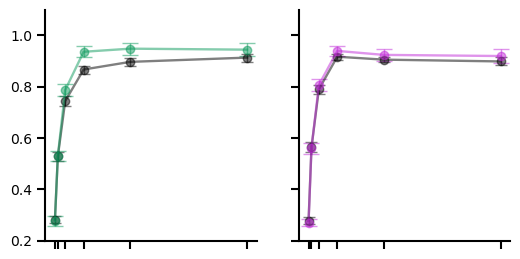

In [39]:
dpiIn = 100

fig,axs = plt.subplots(1,2,figsize = ((6,3)), sharey = True,dpi=dpiIn)
lineW = 1.7

#########################

left_hemifield_resposes = f1_data[:,:,:]
dataDims = np.shape(left_hemifield_resposes)
dataStandErrMeans1 = np.std(left_hemifield_resposes,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans1 = np.nanmean(left_hemifield_resposes,axis = 0)

right_hemifield_resposes = f2_data[:,:,:]
dataStandErrMeans2 = np.std(right_hemifield_resposes,axis = 0) / np.sqrt(int(dataDims[0]))
dataMeans2 = np.nanmean(right_hemifield_resposes,axis = 0)

#########################|

axs[0].errorbar(contrast_location ,dataMeans1[0,:], yerr = dataStandErrMeans1[0,:], label = 'F1 pre', color = 'black',linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='black', markeredgecolor='black', markersize = 6, alpha = 0.5)
axs[0].errorbar(contrast_location,dataMeans1[1,:], yerr = dataStandErrMeans1[1,:], label = 'F1 post', color = "#0D9A5DF5",linewidth = lineW,capsize=6, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='#0D9A5DF5', markeredgecolor="#0D9A5DF5", markersize = 6, alpha = 0.5)

axs[1].errorbar(contrast_location,dataMeans2[0,:], yerr = dataStandErrMeans2[0,:], label = 'F2 pre',  color = 'black',linewidth = lineW,capsize=4, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='black', markeredgecolor='black', markersize = 6, alpha = 0.5)
axs[1].errorbar(contrast_location,dataMeans2[1,:], yerr = dataStandErrMeans2[1,:], label = 'F2 post', color = "#C12AD8",linewidth = lineW,capsize=6, elinewidth=1,linestyle = '-',fmt = 'o', markerfacecolor='#C12AD8', markeredgecolor="#C12AD8", markersize = 6, alpha = 0.5)

#########################
print(f"N Subject per group: {left_hemifield_resposes.shape[0]}, {right_hemifield_resposes.shape[0]}")
#########################
for x in range(2):
    # show only left + bottom
    axs[x].spines['right'].set_visible(False)
    axs[x].spines['top'].set_visible(False)

    # make the visible spines thicker
    for side in ('left', 'bottom'):
        axs[x].spines[side].set_linewidth(1.5)
    axs[x].set_xticks(contrast_location)
    axs[x].tick_params(width=1.5, length=6)
    axs[x].set_xticklabels([])       
    axs[x].set_ylim(yLim_min, yLim_max)